In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, learning_curve
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import shap

# Chargement
from src.config import *
from src.utils import *

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, log_loss, confusion_matrix
)


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#store start time of notebook
start_time = datetime.datetime.now()
print("Start time: ", start_time)

Start time:  2025-06-12 21:33:37.040415


In [ ]:
#load latest final dataset cleaned

final_dataset_file = get_latest_file(DATA_FINAL_CLEANED_DATASET_DIR)

df = pd.read_csv(final_dataset_file)
print("Loaded dataset: ", final_dataset_file)


Loaded dataset:  data\final_cleaned_dataset\nba_features_cleaned_final_2025-06-12_20-02-49.csv


# -------- 1. Analyse rapide --------


In [ ]:
def quick_eda(df):
    display("Colonnes:", df.columns.tolist())
    display("Échantillon:\n", df.tail(4))
    display("Distribution des cibles:\n", df['IS_WIN'].value_counts(normalize=True))
    display("Valeurs manquantes:\n", df.isnull().sum().sort_values(ascending=False).head(10))

    num_cols = df.select_dtypes(include=[np.number]).columns.difference(['IS_WIN'])
    corr = df[num_cols].corr()
    plt.figure(figsize=(20, 16))
    sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Heatmap des corrélations")
    plt.show()

#quick_eda(df)


# -------- 2. Visualisation features clés --------


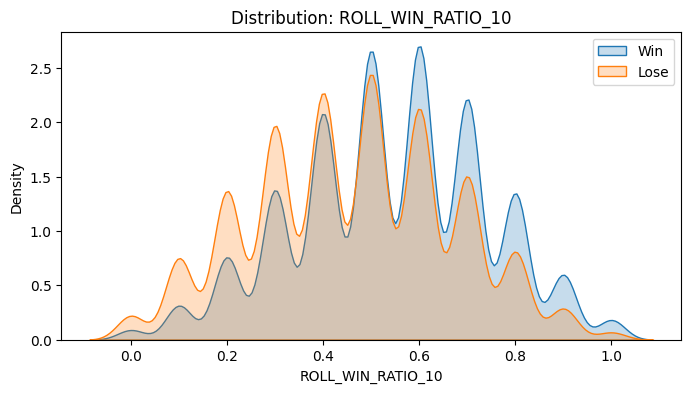

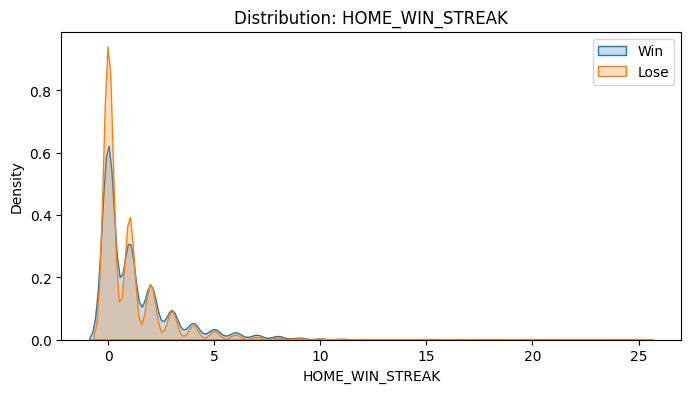

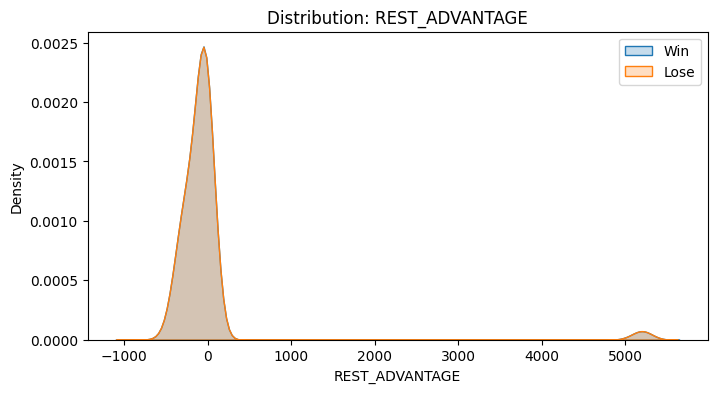

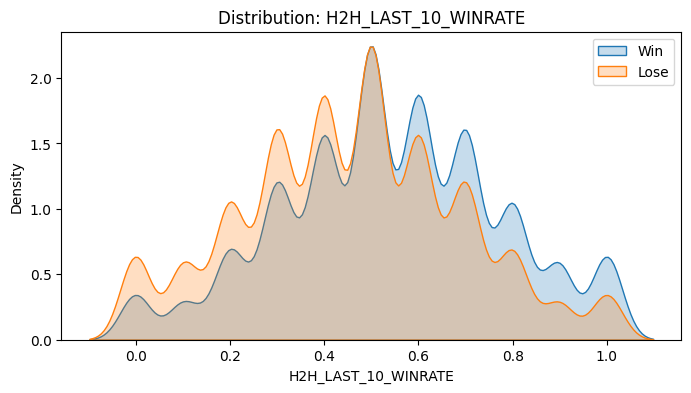

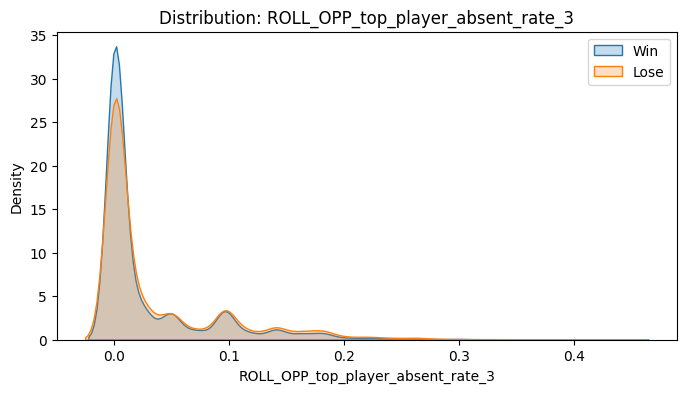

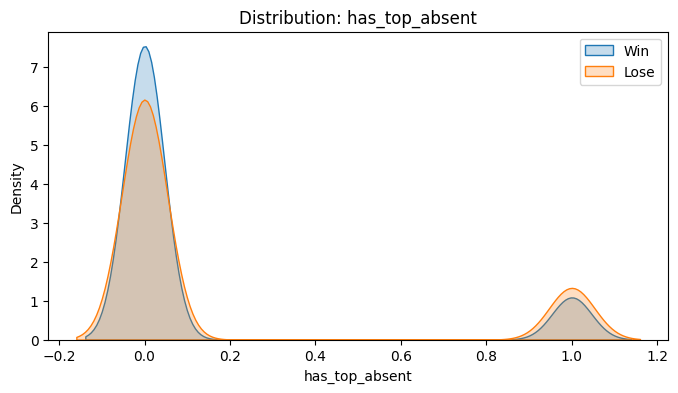

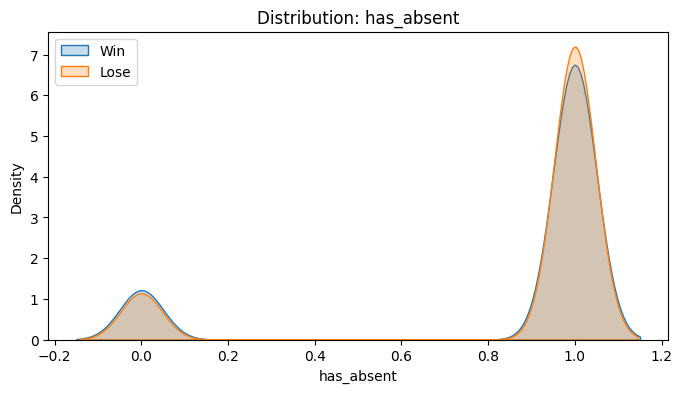

In [ ]:

def plot_feature_distributions(df, features, target='IS_WIN'):
    for feat in features:
        if feat in df.columns:
            plt.figure(figsize=(8, 4))
            sns.kdeplot(df[df[target] == 1][feat].dropna(), label='Win', fill=True)
            sns.kdeplot(df[df[target] == 0][feat].dropna(), label='Lose', fill=True)
            plt.title(f'Distribution: {feat}')
            plt.legend()
            plt.show()

plot_feature_distributions(df, [
    'ROLL_WIN_RATIO_10', 'HOME_WIN_STREAK', 'REST_ADVANTAGE',
    'H2H_LAST_10_WINRATE', 'ROLL_OPP_top_player_absent_rate_3',
    'has_top_absent','has_absent'
])

# -------- 3. Préparation train/test --------


In [ ]:

def prepare_train_test(df, target='IS_WIN', drop_cols=[]):
    features = df.columns.difference([target] + drop_cols)
    df = df.dropna(subset=features)
    X = df[features]
    y = df[target]
    split_index = int(len(df) * 0.8)
    return X.iloc[:split_index], X.iloc[split_index:], y.iloc[:split_index], y.iloc[split_index:]

drop_cols = COLS_TO_DROP_TARGET_IS_WIN + COLS_ODDS
X_train, X_test, y_train, y_test = prepare_train_test(df, drop_cols=drop_cols)


# -------- 4. Modélisation et Évaluation --------

In [ ]:


rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7, use_label_encoder=False, eval_metric='logloss', random_state=42)
evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost")

cat = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.05, random_seed=42, verbose=0)
evaluate_model(cat, X_train, y_train, X_test, y_test, "CatBoost")


========= Random Forest evaluation =========
Accuracy: 0.5741130091984231
Precision: 0.5767862031207227
Recall: 0.5541820094687007
F1 Score: 0.5652582159624413
ROC AUC: 0.6015682673648103
Log Loss: 0.6773502723128537
Confusion Matrix:
 [[2262 1546]
 [1695 2107]]


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:40:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========= XGBoost evaluation =========
Accuracy: 0.6370565045992116
Precision: 0.6444444444444445
Recall: 0.6102051551814834
F1 Score: 0.6268576060524182
ROC AUC: 0.6968117731048231
Log Loss: 0.6291347935543798
Confusion Matrix:
 [[2528 1280]
 [1482 2320]]
========= CatBoost evaluation =========
Accuracy: 0.6486202365308804
Precision: 0.6446153846153846
Recall: 0.6612309310889006
F1 Score: 0.6528174500129836
ROC AUC: 0.7118152791100658
Log Loss: 0.619902977331004
Confusion Matrix:
 [[2422 1386]
 [1288 2514]]


(<catboost.core.CatBoostClassifier at 0x17746473b90>,
 array([0.71774196, 0.32716864, 0.43245676, ..., 0.54915678, 0.3259082 ,
        0.64881744], shape=(7610,)))

# -------- 5. SHAP --------


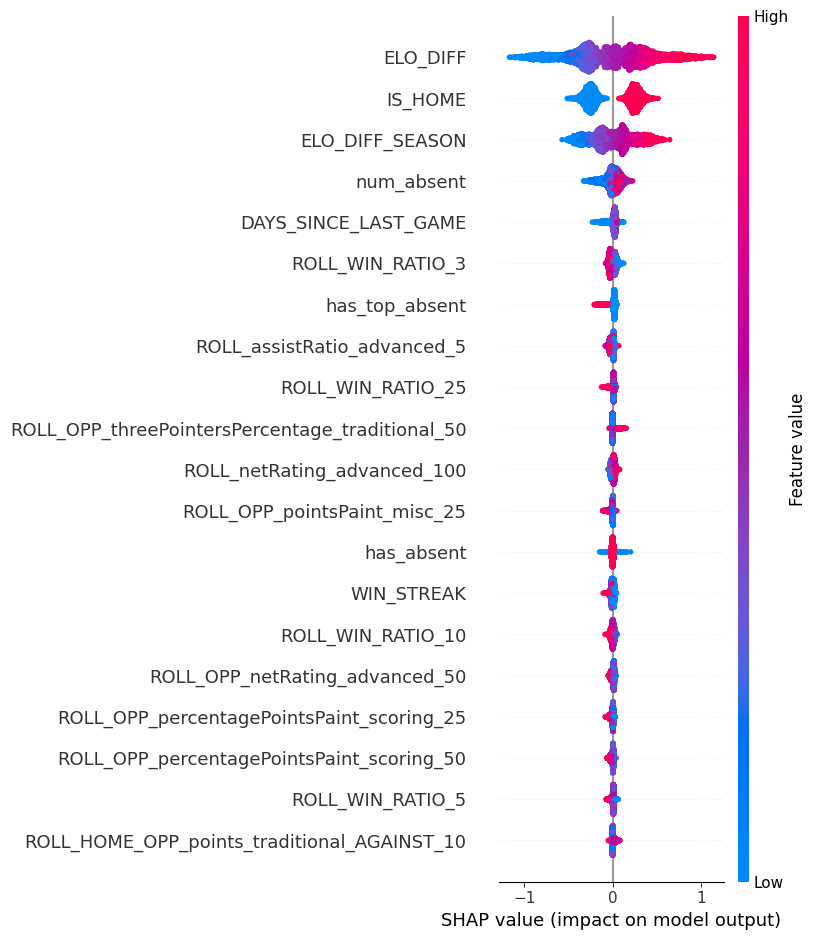

In [ ]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


# -------- 6. TimeSeriesSplit CV --------


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])
scores = cross_val_score(xgb, X_all, y_all, cv=tscv, scoring='roc_auc')
print("TimeSeries CV ROC AUC:", scores.mean())

e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:43:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:44:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# -------- 7. Learning Curves --------


e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:08:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:08:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:09:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\Documents_\Dev\NBA_Predictor\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:10:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "

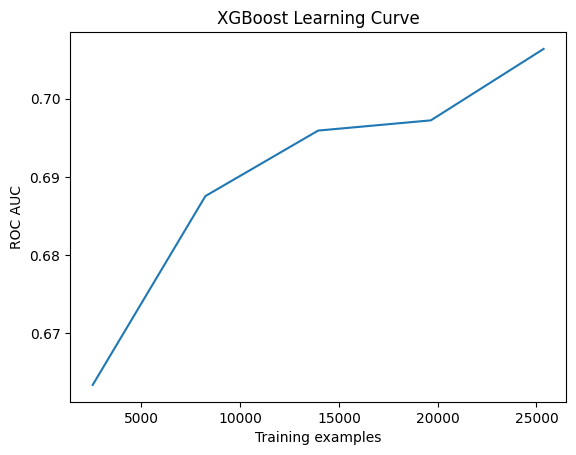

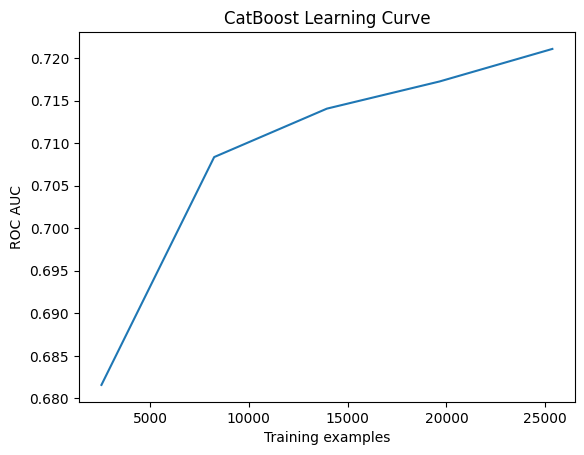

In [ ]:


plot_learning_curve(xgb, pd.concat([X_train, X_test]), pd.concat([y_train, y_test]), "XGBoost")
plot_learning_curve(cat, pd.concat([X_train, X_test]), pd.concat([y_train, y_test]), "CatBoost")

In [ ]:
end_time = datetime.datetime.now()
print("End time: ", end_time)
print("Total execution time: ", end_time - start_time)

End time:  2025-06-12 20:24:21.369845
Total execution time:  0:32:16.403515
